Fundamentals of Deep Learning Models

# Lab 04-1: Optimizers for Deep Neural Networks
## Exercise: Comparing optimization algorithms on MNIST digit classification

This exercise implements and compares five gradient-based optimization algorithms — **SGD**, **SGD with momentum**, **AdaGrad**, **RMSProp**, and **Adam** — introduced in Sections 4.1–4.3 of the textbook. A three-layer neural network trained on the mini-MNIST dataset (sklearn `load_digits`, 8×8 images) is used as the testbed. The core task is to implement each optimizer's parameter update rule (Eqs. 4.1–4.15) within a unified `my_optimizer` function and observe how they affect convergence behavior.

**Note:** The forward/backward propagation and mini-batch splitting functions are reused from Lab 03-3 (Chapter 3). This lab focuses on the optimizer implementations. Although the textbook presents SGD as a per-sample update (Eq. 4.2), this exercise uses **mini-batch gradient descent** (Eq. 4.7) for all optimizers.

### Prepare mini-MNIST dataset

The dataset is `sklearn.datasets.load_digits`, which contains 1,797 images of handwritten digits (0–9), each represented as an 8×8 pixel grayscale image ($N = 1797$, $M = 64$ features). The pixel values range from 0 to 16. We split the data into 80% training and 20% test sets, then apply `StandardScaler` to normalize features to zero mean and unit variance — this prevents large exponential values in the sigmoid activation. The target labels are converted to one-hot vectors ($K = 10$ classes) for multi-class cross-entropy loss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version

print('Numpy version:', np.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('scikit-learn version:', sklearn_version)

Numpy version: 2.0.2
Matplotlib version: 3.10.0
scikit-learn version: 1.6.1


In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()

# Flatten 8x8 images into 64-dimensional feature vectors
digits_df = digits.images.reshape((len(digits.target), -1))
digits_tf = digits.target

# Split into training (80%) and test (20%) sets
X_train_org, X_test_org, y_train_num, y_test = train_test_split(
    digits_df, digits_tf, test_size=0.20, random_state=101)

# Standardize features to zero mean and unit variance
sc = StandardScaler()
X_train = sc.fit_transform(X_train_org)
X_test = sc.transform(X_test_org)

n_classes = 10

# Convert integer labels to one-hot encoded vectors (N x 10)
y_train = np.zeros((y_train_num.shape[0], 10))
for i in range(n_classes):
    y_train[:, i] = (y_train_num == i)

#### Define utility functions

Sigmoid and softmax are imported from TensorFlow for numerical stability and wrapped as NumPy-compatible functions.

In [3]:
from tensorflow.math import sigmoid as tf_sigmoid
from tensorflow.nn import softmax as tf_softmax

def sigmoid(x):
    x = tf_sigmoid(x)
    return x.numpy()

def softmax(x):
    x = tf_softmax(x)
    return x.numpy()

(1797, 64)
(1437, 64)
(1437, 10)
[ 0.  0.  0.  9. 16.  6.  0.  0.  0.  0.  4. 15.  6. 15.  0.  0.  0.  0.
  8. 11.  9. 11.  0.  0.  0.  0.  8. 16. 14.  2.  0.  0.  0.  0. 11. 16.
 13.  0.  0.  0.  0.  6. 14.  2. 12.  9.  0.  0.  0.  5. 16. 11.  5. 13.
  4.  0.  0.  0.  3.  8. 13. 16.  9.  0.]


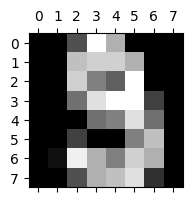

The number is 9


In [4]:
print(digits_df.shape)
print(X_train.shape)
print(y_train.shape)
print(X_train_org[0])

idx = np.random.randint(X_train.shape[0])
dimage = X_train_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()
print('The number is', y_train_num[idx])

### Simple DNN for digit classification

The following cells define a three-layer fully connected network with sigmoid activations in hidden layers and softmax at the output, reused from Lab 03-3 (Chapter 3). The forward and backward propagation follow the generalized backpropagation procedure (Eqs. 3.28–3.31).

#### Define model class (from Lab 03-3)

In [ ]:
class myDenseLayer:
    def __init__(self, n_out, n_in):
        self.weight = np.empty((n_out, n_in))
        self.bias = np.zeros((n_out))
        self.saved_x = None     # store x to use while backpropagation

    def forward(self, x):   # x: (b, i)

        ### START CODE HERE ###

        # Save input for use in backward pass
        self.saved_x = None
        # Compute linear transformation: z = W * x^T + b  (Eq. 3.28)
        x_lin = None

        ### END CODE HERE ###

        return x_lin

    def backward(self, x):    # x = dJ/dz (b, c)

        ### START CODE HERE ###

        # Compute weight gradient: dJ/dW = (dJ/dz)^T * a^{[l-1]} / N  (Eq. 3.30)
        dw = None
        # Compute bias gradient: dJ/db = mean(dJ/dz)  (Eq. 3.31)
        db = None
        # Propagate gradient to lower layer: W^T * dJ/dz  (Eq. 3.29)
        wdJdz = None

        ### END CODE HERE ###

        return dw, db, wdJdz

#### Define backpropagation through activation functions (from Lab 03-3)

In [ ]:
def dJdz_sigmoid(wdJdz_upper, a_l):

    ### START CODE HERE ###

    # Element-wise: dJ/dz = (W^T dJ/dz_upper) * a * (1 - a)  (Eq. 3.29)
    dJdz = None

    ### END CODE HERE ###

    return dJdz

def dJdz_softmax(y_hat, y):

    ### START CODE HERE ###
    
    # Softmax + cross-entropy gradient: dJ/dz = y_hat - y  (Eq. 3.32)
    dJdz = None
    
    ### END CODE HERE ###
    
    return dJdz

#### Define training functions (from Lab 03-3)

In [ ]:
def my_forward(layers, X_in):
    l1, l2, l3 = layers

    ### START CODE HERE ###

    # Layer 1: sigmoid activation
    a_1 = None
    # Layer 2: sigmoid activation
    a_2 = None
    # Layer 3: softmax output
    a_3 = None

    ### END CODE HERE ###

    return a_1, a_2, a_3

def my_backward(layers, a_1, a_2, a_3, y_true):
    l1, l2, l3 = layers

    ### START CODE HERE ###

    # Backpropagate through layer 3 (softmax + cross-entropy)
    dw_3, db_3, wdJdz_3 = None
    # Backpropagate through layer 2 (sigmoid)
    dw_2, db_2, wdJdz_2 = None
    # Backpropagate through layer 1 (sigmoid)
    dw_1, db_1, _       = None

    ### END CODE HERE ###

    d_1 = [dw_1, db_1]
    d_2 = [dw_2, db_2]
    d_3 = [dw_3, db_3]

    return d_1, d_2, d_3

def my_loss(layers, X_in, y_true):
    l1, l2, l3 = layers

    ### START CODE HERE ###

    # Forward pass to compute predictions
    a_1 = None
    a_2 = None
    a_3 = None
    # Cross-entropy loss: L = -mean(sum(y * log(y_hat)))  (Eq. 3.16)
    loss = None

    ### END CODE HERE ###

    return loss

def my_predict(layers, X_in):
    l1, l2, l3 = layers

    ### START CODE HERE ###

    # Forward pass and return class with highest probability
    a_1 = None
    a_2 = None
    a_3 = None
    pred = None

    ### END CODE HERE ###

    return pred

#### Create a NN model and check matrix dimensions

In [8]:
n_inputs  = 64
n_hidden1 = 80
n_hidden2 = 70
n_classes = 10

l1 = myDenseLayer(n_hidden1, n_inputs)
l2 = myDenseLayer(n_hidden2, n_hidden1)
l3 = myDenseLayer(n_classes, n_hidden2)

layers = [l1, l2, l3]

print(X_train.shape, y_train.shape)
print(l1.weight.shape, l1.bias.shape)
print(l2.weight.shape, l2.bias.shape)
print(l3.weight.shape, l3.bias.shape)

(1437, 64) (1437, 10)
(80, 64) (80,)
(70, 80) (70,)
(10, 70) (10,)


### Define a function for splitting dataset into mini-batches

Mini-batch gradient descent (Eq. 4.7) randomly partitions the training data into groups of size `batch_size`. Data is shuffled at each call to ensure randomness across epochs. If the dataset size is not divisible by `batch_size`, the remaining samples form a smaller final batch.

In [ ]:
def create_mini_batches(X, y, batch_size=64):
    mini_batches = []
    n_minibatches = (X.shape[0] // batch_size)
    n_variables = X.shape[1]

    ### START CODE HERE ###

    # Concatenate features and labels, then shuffle
    data = None
    np.random.shuffle(data)

    # Create full-sized mini-batches
    for i in range(n_minibatches):
        mini_batch = None
        X_mini, y_mini = None
        mini_batches.append((X_mini, y_mini))

    # Handle remainder batch if dataset size is not divisible by batch_size
    if data.shape[0] % batch_size != 0:
        mini_batch = None
        X_mini, y_mini = None
        mini_batches.append((X_mini, y_mini))

    ### END CODE HERE ###

    return mini_batches

In [10]:
np.random.seed(1)

a = np.arange(20).reshape(10, 2)
b = -np.arange(10, 20).reshape(10, 1)

c = create_mini_batches(a, b, 4)
for mini_X, mini_y in c:
    print(mini_X)
    print(mini_y, '\n')

[[ 4  5]
 [18 19]
 [12 13]
 [ 8  9]]
[[-12]
 [-19]
 [-16]
 [-14]] 

[[ 0  1]
 [ 6  7]
 [ 2  3]
 [14 15]]
[[-10]
 [-13]
 [-11]
 [-17]] 

[[16 17]
 [10 11]]
[[-18]
 [-15]] 



**Expected output** (ignore column format):
```
[[ 4  5]          [[ 0  1]           [[16 17]
 [18 19]           [ 6  7]            [10 11]]
 [12 13]           [ 2  3]           [[-18]
 [ 8  9]]          [14 15]]           [-15]]  
[[-12]            [[-10]             
 [-19]             [-13]             
 [-16]             [-11]             
 [-14]]            [-17]]              
```

## Define various optimizers

The following implements five optimization algorithms from Sections 4.1–4.3. All use **mini-batch gradients** $\mathbf{g}_t$ computed from a randomly sampled subset of training data (Eq. 4.7).

**SGD** (Eq. 4.1): $\quad \Delta\boldsymbol{\theta}_t = \alpha\, \mathbf{g}_t$

**SGD with momentum** (Eq. 4.3): $\quad \Delta\boldsymbol{\theta}_t = \gamma\, \Delta\boldsymbol{\theta}_{t-1} + \alpha\, \mathbf{g}_t$

**AdaGrad** (Eqs. 4.8–4.9): $\quad \mathbf{v}_t = \mathbf{v}_{t-1} + \mathbf{g}_t^2, \quad \Delta\boldsymbol{\theta}_t = \alpha\, \mathbf{g}_t \oslash \sqrt{\mathbf{v}_t + \epsilon}$

**RMSProp** (Eq. 4.10): $\quad \mathbf{v}_t = \beta\, \mathbf{v}_{t-1} + (1-\beta)\, \mathbf{g}_t^2, \quad \Delta\boldsymbol{\theta}_t = \alpha\, \mathbf{g}_t \oslash \sqrt{\mathbf{v}_t + \epsilon}$

**Adam** (Eqs. 4.11–4.15):
$$\mathbf{m}_t = \beta_1\, \mathbf{m}_{t-1} + (1-\beta_1)\, \mathbf{g}_t, \quad \mathbf{v}_t = \beta_2\, \mathbf{v}_{t-1} + (1-\beta_2)\, \mathbf{g}_t^2$$
$$\widehat{\mathbf{m}}_t = \frac{\mathbf{m}_t}{1-\beta_1^t}, \quad \widehat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1-\beta_2^t}, \quad \boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \alpha\, \frac{\widehat{\mathbf{m}}_t}{\sqrt{\widehat{\mathbf{v}}_t} + \epsilon}$$

All optimizers update parameters as $\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \Delta\boldsymbol{\theta}_t$.

**Note:** The Adam implementation below uses $\beta_2 = 0.99$ (instead of the textbook default of $0.999$) for faster adaptation in this small-scale experiment.

In [ ]:
class myOptParam:
    def __init__(self, n_out, n_in):
        # Previous delta values for momentum optimizer
        self.W_dt = np.zeros((n_out, n_in))
        self.B_dt = np.zeros(n_out)
        # First moment (m_t) for Adam
        self.W_mt = np.zeros((n_out, n_in))
        self.B_mt = np.zeros(n_out)
        # Second moment (v_t) for AdaGrad, RMSProp, Adam
        self.W_vt = np.zeros((n_out, n_in))
        self.B_vt = np.zeros(n_out)

def my_optimizer(lyr, opt, W_grad, B_grad, solver='sgd', learning_rate=0.01, iter=1):
    epsilon = 1e-8  # small constant to prevent division by zero
    alpha = eta = learning_rate

    if iter == 0:
        print('iteration should start from 1.')

    # --- Optimizer routines ---
    if solver == 'sgd':
        # SGD update: delta = alpha * g_t  (Eq. 4.1)
        W_dlt = alpha * W_grad
        B_dlt = alpha * B_grad

    elif solver == 'momentum':
        gamma = 0.9

        ### START CODE HERE ###

        # Momentum update: delta_t = gamma * delta_{t-1} + alpha * g_t  (Eq. 4.3)
        W_dlt = None
        B_dlt = None
        # Store current delta for next iteration
        opt.W_dt = None
        opt.B_dt = None

        ### END CODE HERE ###

    elif solver == 'adagrad':

        ### START CODE HERE ###

        # Accumulate squared gradients: v_t = v_{t-1} + g_t^2  (Eq. 4.8)
        opt.W_vt = None
        opt.B_vt = None
        # Adaptive update: delta = eta * g_t / sqrt(v_t + epsilon)  (Eq. 4.9)
        W_dlt = None
        B_dlt = None

        ### END CODE HERE ###

    elif solver == 'rmsprop':
        beta2 = 0.9

        ### START CODE HERE ###

        # EMA of squared gradients: v_t = beta * v_{t-1} + (1-beta) * g_t^2  (Eq. 4.10)
        opt.W_vt = None
        opt.B_vt = None
        # Adaptive update: delta = eta * g_t / sqrt(v_t + epsilon)  (Eq. 4.9)
        W_dlt = None
        B_dlt = None

        ### END CODE HERE ###

    elif solver == 'adam':
        beta1, beta2 = 0.9, 0.99  # Note: textbook default is beta2=0.999

        ### START CODE HERE ###

        # First moment EMA: m_t = beta1 * m_{t-1} + (1-beta1) * g_t  (Eq. 4.11)
        opt.W_mt = None
        opt.B_mt = None
        # Second moment EMA: v_t = beta2 * v_{t-1} + (1-beta2) * g_t^2  (Eq. 4.12)
        opt.W_vt = None
        opt.B_vt = None
        # Bias correction  (Eqs. 4.13, 4.14)
        W_mc = None
        B_mc = None
        W_vc = None
        B_vc = None
        # Adam update: theta -= alpha * m_hat / (sqrt(v_hat) + epsilon)  (Eq. 4.15)
        W_dlt = None
        B_dlt = None

        ### END CODE HERE ###

    else:
        print('optimizer error')

    # Apply parameter update: theta_t = theta_{t-1} - delta_t
    lyr.weight = lyr.weight - W_dlt
    lyr.bias = lyr.bias - B_dlt

    return

#### Optimizer test

In [12]:
np.random.seed(101)

lyr = myDenseLayer(2, 3)
opt = myOptParam(2, 3)

lyr.weight = np.random.randn(2, 3)
lyr.bias = np.random.randn(2)
opt.W_dt = np.random.randn(2, 3)
opt.B_dt = np.random.randn(2)
opt.W_mt = np.random.randn(2, 3)
opt.B_mt = np.random.randn(2)
opt.W_vt = np.abs(np.random.randn(2, 3))
opt.B_vt = np.abs(np.random.randn(2))

W_grad = np.random.randn(2, 3)
B_grad = np.random.randn(2)

# Test each optimizer sequentially (cumulative updates)
opts = ['sgd', 'momentum', 'adagrad', 'rmsprop', 'adam']
expt = [[ 7.67789007,  8.16882972, 10.34203348, -3.22934657],
        [14.46528172, 15.04341688, 19.30016537, -4.77070266],
        [22.50872929, 22.74302212, 28.47667875, -7.62607443],
        [30.69802889, 30.60433129, 37.72651766, -10.62235939],
        [29.41774022, 19.27573813, 23.68071186,   1.52919472]]
test_passed = True
for i, sol in enumerate(opts):
    my_optimizer(lyr, opt, W_grad, B_grad, sol, 10, 3)
    print('For ' + sol + ':')
    res = np.concatenate((lyr.weight[0], lyr.bias[0:1]), axis=0)
    print(res)
    if not np.allclose(res, expt[i]):
        print(sol + ' failed.')
        test_passed = False
if test_passed:
    print('test passed.')
else:
    print('test failed.')

For sgd:
[ 7.67789007  8.16882972 10.34203348 -3.22934657]
For momentum:
[14.46528172 15.04341688 19.30016537 -4.77070266]
For adagrad:
[22.50872929 22.74302212 28.47667875 -7.62607443]
For rmsprop:
[ 30.69802889  30.60433129  37.72651766 -10.62235939]
For adam:
[29.41774022 19.27573813 23.68071186  1.52919472]
test passed.


**Expected output:**

For SGD:
```
[ 7.67789007  8.16882972 10.34203348 -3.22934657]
```
For Momentum:
```
[14.46528172 15.04341688 19.30016537 -4.77070266]
```
For AdaGrad:
```
[22.50872929 22.74302212 28.47667875 -7.62607443]
```
For RMSProp:
```
[ 30.69802889  30.60433129  37.72651766 -10.62235939]
```
For Adam:
```
[29.41774022 19.27573813 23.68071186  1.52919472]
```

#### Create optimizer parameters

In [13]:
o1 = myOptParam(n_hidden1, n_inputs)
o2 = myOptParam(n_hidden2, n_hidden1)
o3 = myOptParam(n_classes, n_hidden2)

#### Weight initialization

Weights are initialized from a standard normal distribution $\mathcal{N}(0, 1)$. For improved training stability, Xavier initialization (Eq. 4.20) or He initialization (Eq. 4.22) could be used depending on the activation function. Biases are initialized to zero.

In [14]:
np.random.seed()

# Initialize weights from standard normal distribution
# Biases are set to zeros during layer creation
l1.weight = np.random.randn(n_hidden1, n_inputs)
l2.weight = np.random.randn(n_hidden2, n_hidden1)
l3.weight = np.random.randn(n_classes, n_hidden2)

### Training the neural network model

Train the 3-layer model using mini-batch gradient descent with the selected optimizer. Change the `optimizer` variable to compare convergence behavior across SGD, momentum, AdaGrad, RMSProp, and Adam.

In [ ]:
# optimizer settings: 'sgd', 'momentum', 'adagrad', 'rmsprop', 'adam'
optimizer = 'sgd'
alpha = 0.01
n_epochs = 1000

for epoch in range(n_epochs):

    batches = create_mini_batches(X_train, y_train, batch_size=64)
    for one_batch in batches:
        X_mini, y_mini = one_batch
        batch_len = X_mini.shape[0]  # last batch might have different length

        # Forward pass
        a_1, a_2, a_3 = my_forward(layers, X_mini)

        # Backward pass
        d_1, d_2, d_3 = my_backward(layers, a_1, a_2, a_3, y_mini)

        dw_1, db_1 = d_1
        dw_2, db_2 = d_2
        dw_3, db_3 = d_3

        # Update weights and biases using the selected optimizer
        my_optimizer(l1, o1, dw_1, db_1, solver=optimizer, learning_rate=alpha, iter=epoch+1)
        my_optimizer(l2, o2, dw_2, db_2, solver=optimizer, learning_rate=alpha, iter=epoch+1)
        my_optimizer(l3, o3, dw_3, db_3, solver=optimizer, learning_rate=alpha, iter=epoch+1)

    if ((epoch + 1) % 100 == 0):
        loss_J = my_loss(layers, X_train, y_train)
        print('Epoch: %4d,  loss: %10.8f' % (epoch + 1, loss_J))
        if loss_J < 1e-9:
            break

Epoch:  100,  loss: 0.58270975
Epoch:  200,  loss: 0.30959280
Epoch:  300,  loss: 0.20681165
Epoch:  400,  loss: 0.14978831
Epoch:  500,  loss: 0.11337223
Epoch:  600,  loss: 0.08876815
Epoch:  700,  loss: 0.07199040
Epoch:  800,  loss: 0.06015157
Epoch:  900,  loss: 0.05135664
Epoch: 1000,  loss: 0.04460119


### Evaluate model performance

Compute classification accuracy on the test set using the trained model.

In [16]:
from sklearn.metrics import accuracy_score

y_pred = my_predict(layers, X_test)

accuracy_score(y_pred, y_test)

0.9277777777777778

### Comparison with scikit-learn

Compare with `MLPClassifier` from scikit-learn, which uses the same SGD optimizer with logistic (sigmoid) activation. Note that scikit-learn's implementation includes additional optimizations such as adaptive learning rate and L2 regularization (`alpha` parameter) that may affect results.

In [17]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(80, 70,), activation='logistic', solver='sgd',
                    alpha=0.01, learning_rate_init=0.01, max_iter=1000)

# Training the model
mlp.fit(X_train, y_train_num)

# Evaluate on test set
s_pred = mlp.predict(X_test)
accuracy_score(s_pred, y_test)

0.9694444444444444

### Test model with a random sample

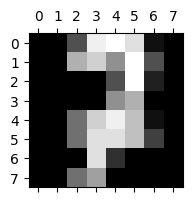

My prediction is 7
sk prediction is 7
Actual number is 7


In [18]:
idx = np.random.randint(X_test.shape[0])
dimage = X_test_org[idx].reshape((8, 8))
plt.figure(figsize=(2, 2))
plt.gray()
plt.matshow(dimage, fignum=0)
plt.show()

X_input = np.expand_dims(X_test[idx], 0)

y_pred = my_predict(layers, X_input)

s_pred = mlp.predict(X_input)

print('My prediction is ' + str(y_pred[0]))
print('sk prediction is ' + str(s_pred[0]))
print('Actual number is ' + str(y_test[idx]))

(c) 2026 S. W. Lee